In [1]:
import pandas as pd
import numpy as np
import optuna
from optuna.samplers import TPESampler
import lightgbm as lgb
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

/opt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ==========================================
# 1. 원천(Raw) 데이터 로드 (기존 병합본 폐기)
# ==========================================
info_df = pd.read_csv('/Users/kwagminseo/Documents/SAS/data/train/train_customer_info.csv')
finance_df = pd.read_csv('/Users/kwagminseo/Documents/SAS/data/train/train_finance_profile.csv')
trans_df = pd.read_csv('/Users/kwagminseo/Documents/SAS/data/train/train_transaction_history.csv')
targets_df = pd.read_csv('/Users/kwagminseo/Documents/SAS/data/train/train_targets.csv')

In [3]:
# 2. RFM 지표 추출 (transaction_history 기준)
trans_df['trans_date'] = pd.to_datetime(trans_df['trans_date'])
base_date = pd.to_datetime('2023-12-31')
recent_1m_date = base_date - pd.Timedelta(days=30)

# 1. 기간별 RFM 추출 함수 (7, 15, 30, 90일)
def get_period_rfm(df, end_date, days):
    cutoff = end_date - pd.Timedelta(days=days)
    temp = df[df['trans_date'] >= cutoff]
    return temp.groupby('customer_id').agg(
        freq=(f'trans_id', 'count'),
        money=(f'trans_amount', 'sum')
    )

# 각 기간별 RFM 생성
rfm_7d  = get_period_rfm(trans_df, base_date, 7).rename(columns={'freq':'freq_7d', 'money':'money_7d'})
rfm_15d = get_period_rfm(trans_df, base_date, 15).rename(columns={'freq':'freq_15d', 'money':'money_15d'})
rfm_1m  = get_period_rfm(trans_df, base_date, 30).rename(columns={'freq':'freq_1m', 'money':'money_1m'})
rfm_3m  = get_period_rfm(trans_df, base_date, 90).rename(columns={'freq':'freq_3m', 'money':'money_3m'})

# 1-1. 전체 기간 RFM
rfm_total = trans_df.groupby('customer_id').agg(
    Recency=('trans_date', lambda x: (base_date - x.max()).days),
    Frequency=('trans_id', 'count'),
    Monetary=('trans_amount', 'sum')
).reset_index()

# 모든 기간 데이터 병합
rfm_df = rfm_total.merge(rfm_7d, on='customer_id', how='left') \
               .merge(rfm_15d, on='customer_id', how='left') \
               .merge(rfm_1m, on='customer_id', how='left') \
               .merge(rfm_3m, on='customer_id', how='left').fillna(0)

# 2. 🌟 구매 주기(Interval) 및 변동성(Std) 계산
trans_df = trans_df.sort_values(['customer_id', 'trans_date'])
# 고객별 결제일 간의 차이(일수) 계산
trans_df['days_diff'] = trans_df.groupby('customer_id')['trans_date'].diff().dt.days
interval_stats = trans_df.groupby('customer_id')['days_diff'].agg(['mean', 'std']).reset_index()
interval_stats.columns = ['customer_id', 'avg_interval', 'interval_std']
interval_stats.fillna(0, inplace=True) # 결제가 1건뿐인 경우 0 처리

rfm_df = rfm_df.merge(interval_stats, on='customer_id', how='left')

# ==============================================================================
# 🔥 [고급 파생변수] 모델의 변별력을 높이는 킬러 피처들
# ==============================================================================

# 1. 상대적 최신성: 평소 주기 대비 현재 얼마나 늦었는가? (1보다 크면 위험)
rfm_df['relative_recency'] = rfm_df['Recency'] / (rfm_df['avg_interval'] + 1e-6)

# 2. 신뢰도 기반 위험도: 주기가 일정했던(std 낮음) 사람이 주기를 어기면 위험도 폭증
rfm_df['consistency_risk'] = rfm_df['relative_recency'] * (1 / (rfm_df['interval_std'] + 1))

# 3. 단기 소비 급감량 (7일/15일 실적이 평소 1달 평균 대비 얼마나 줄었나)
rfm_df['avg_monthly_Monetary'] = rfm_df['Monetary'] / 6
rfm_df['short_term_drop_7d'] = (rfm_df['avg_monthly_Monetary'] / 4) - rfm_df['money_7d']
rfm_df['short_term_drop_15d'] = (rfm_df['avg_monthly_Monetary'] / 2) - rfm_df['money_15d']

# 4. 건당 결제액 (Ticket Size)
rfm_df['avg_ticket_size'] = rfm_df['Monetary'] / (rfm_df['Frequency'] + 1e-6)

print("✅ 7일/15일 지표 및 주기성 분석이 포함된 RFM 변수 생성이 완료되었습니다!")

# =============================================================
# 🎯 확률 분포 분리를 위한 '익스트림(Extreme)' 파생변수 생성
# =============================================================

# 1. 초단기 완전 중단 Flag (이게 분포를 끝으로 밀어줍니다)
rfm_df['is_silent_7d'] = (rfm_df['money_7d'] == 0).astype(int)
rfm_df['is_silent_15d'] = (rfm_df['money_15d'] == 0).astype(int)

# 2. 주기 파괴 지수 (Consistency Breakdown)
# 평소 주기보다 3배 이상 늦어지면 1, 아니면 0 (트리가 가장 좋아하는 변수)
rfm_df['cycle_break_3x'] = (rfm_df['Recency'] > rfm_df['avg_interval'] * 3).astype(int)

# 3. 상대적 최신성의 로그 변환 (분포의 꼬리를 늘려줍니다)
# 1e-6 대신 1을 더해 안정성을 높이고 로그를 씌워 변별력 강화
rfm_df['log_relative_recency'] = np.log1p(rfm_df['Recency'] / (rfm_df['avg_interval'] + 1))

# 4. 결제 모멘텀의 가속도 (Acceleration)
# 3개월 평균 대비 최근 15일 소비의 비율 (급격한 변화 포착)
rfm_df['momentum_15d_vs_3m'] = rfm_df['money_15d'] / (rfm_df['money_3m'] / 6 + 1e-6)

# 5. 기존 변수 유지하되 0으로 쏠리는 것 방지

✅ 7일/15일 지표 및 주기성 분석이 포함된 RFM 변수 생성이 완료되었습니다!


In [4]:
# 2. 취향 일치도 (선호 카테고리 vs 실제 구매)
temp_trans = trans_df.merge(info_df[['customer_id', 'prefer_category']], on='customer_id', how='left')
temp_trans['is_pref_spend'] = (temp_trans['item_category'] == temp_trans['prefer_category']).astype(int)
temp_trans['pref_category_amount'] = temp_trans['trans_amount'] * temp_trans['is_pref_spend']

pref_match_df = temp_trans.groupby('customer_id').agg(
    pref_spend_ratio=('pref_category_amount', lambda x: x.sum() / (temp_trans.loc[x.index, 'trans_amount'].sum() + 1e-6))
).reset_index()

In [5]:
# ==============================================================================
# 2. 재무/부채 파생 변수 고도화
# ==============================================================================
finance_df['has_overdue'] = (finance_df['fin_overdue_days'] > 0).astype(int)
finance_df['has_cash_svc'] = (finance_df['card_cash_service_amt'] > 0).astype(int)
finance_df['has_card_loan'] = (finance_df['card_loan_amt'] > 0).astype(int)
finance_df['total_debt'] = finance_df['card_cash_service_amt'] + finance_df['card_loan_amt'] + finance_df['total_loan_balance']

# 🔥 킬러 파생변수 3: 부채 압박 지수 (Debt to Asset Ratio)
# 예금 잔액 대비 총 부채의 비율 (이 수치가 비정상적으로 높으면 한계차주/비자발적 이탈 위험)
finance_df['debt_to_asset_ratio'] = np.log1p(finance_df['total_debt'] / (finance_df['total_deposit_balance'] + 1))

# 자산 변동 추세 구간화
bins = [-np.inf, -2, 0, 2, np.inf]
labels = [3, 2, 1, 0]
finance_df['asset_trend_risk'] = pd.cut(finance_df['fin_asset_trend_score'], bins=bins, labels=labels).astype(int)

In [6]:
# 3. 데이터 병합
df = info_df.merge(rfm_df, on='customer_id', how='left')
df = df.merge(finance_df, on='customer_id', how='left')
df = df.merge(targets_df, on='customer_id', how='inner')

df.head()


,customer_id,join_date,age,gender,region_code,is_married,prefer_category,income_group,Recency,Frequency,...,fin_overdue_days,fin_asset_trend_score,has_overdue,has_cash_svc,has_card_loan,total_debt,debt_to_asset_ratio,asset_trend_risk,target_churn,target_ltv
0,C000001,2020-04-12,36,F,R03,1,Grocery,G4,4,21,...,0,0.551107,0,1,1,58774802,3.192296,1,0,556691.00
1,C000002,2021-03-11,32,F,R02,0,Home,G3,2,14,...,0,-0.342776,0,1,0,33613861,3.921066,2,0,1460203.00
2,C000003,2022-05-10,41,M,R03,1,Fashion,G3,0,16,...,1,-0.949003,1,1,0,4092,0.000236,2,0,605476.00
3,C000004,2020-09-27,23,F,R02,1,Electronics,G3,7,22,...,0,-0.348409,0,0,0,0,0.000000,2,0,1034150.00
4,C000006,2020-03-12,31,F,R04,0,Grocery,G3,36,14,...,0,0.647922,0,0,1,1906890,1.006466,1,1,76083.15


In [7]:
# ==============================================================================
# [STEP 2] 🚨 에러 원인 제거: 범주형 변수를 Category 타입으로 지정 (Label 인코딩 X)
# ==============================================================================
# LightGBM이 알아서 최적의 분할을 찾도록 category 타입으로만 묶어줍니다.
cat_cols = ['gender', 'region_code', 'prefer_category', 'income_group']
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')

# 학습에 방해되는 날짜 및 타겟 컬럼 제거
drop_cols = ['customer_id', 'target_churn', 'target_ltv', 'join_date', 'trans_date']
features = [col for col in df.columns if col not in drop_cols]

X = df[features]
y = df['target_churn']

In [8]:
# ==============================================================================
# [STEP 3] Train / Valid 분할 (Stratified 적용)
# ==============================================================================
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 불균형 데이터 극복을 위한 이탈(1) 클래스 가중치 계산 (약 9배)
scale_weight = ((len(y_train) - y_train.sum()) / y_train.sum())
print(f"✅ 전처리 완료! 조정된 불균형 가중치: {scale_weight:.2f}")

✅ 전처리 완료! 조정된 불균형 가중치: 9.12


In [9]:
# ==============================================================================
# [STEP 4] K-Fold 교차 검증 + Optuna 하이퍼파라미터 최적화
# ==============================================================================
def objective(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.05, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'num_leaves': trial.suggest_int('num_leaves', 10, 100),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
        'scale_pos_weight': scale_weight,  # 🚨 SMOTE 대신 내장 가중치 사용!
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1
    }
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    auc_scores = []
    
    for train_idx, val_idx in cv.split(X_train, y_train):
        X_fold_train, y_fold_train = X_train.iloc[train_idx], y_train.iloc[train_idx]
        X_fold_valid, y_fold_valid = X_train.iloc[val_idx], y_train.iloc[val_idx]
        
        # SMOTE 없이 원본 데이터로 바로 학습
        model = lgb.LGBMClassifier(**param)
        model.fit(X_fold_train, y_fold_train)
        
        preds = model.predict_proba(X_fold_valid)[:, 1]
        auc = roc_auc_score(y_fold_valid, preds)
        auc_scores.append(auc)
        
    return np.mean(auc_scores)

print("\n▶️ Optuna 하이퍼파라미터 탐색을 시작합니다...")
study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study.optimize(objective, n_trials=15)  # 필요시 50으로 늘리세요

print(f"\n🥇 Best Trial AUC: {study.best_trial.value:.4f}")

[I 2026-04-13 00:39:43,523] A new study created in memory with name: no-name-09c59ab8-4815-47ef-8289-8b881bdcb5b8



▶️ Optuna 하이퍼파라미터 탐색을 시작합니다...


[I 2026-04-13 00:40:06,703] Trial 0 finished with value: 0.7664659231361318 and parameters: {'n_estimators': 562, 'learning_rate': 0.044635901521768134, 'max_depth': 8, 'num_leaves': 64, 'min_child_samples': 16}. Best is trial 0 with value: 0.7664659231361318.
[I 2026-04-13 00:40:24,970] Trial 1 finished with value: 0.7911822964768538 and parameters: {'n_estimators': 409, 'learning_rate': 0.00571549193815661, 'max_depth': 9, 'num_leaves': 64, 'min_child_samples': 39}. Best is trial 1 with value: 0.7911822964768538.
[I 2026-04-13 00:40:31,744] Trial 2 finished with value: 0.7871128493091197 and parameters: {'n_estimators': 314, 'learning_rate': 0.04665303012212833, 'max_depth': 8, 'num_leaves': 29, 'min_child_samples': 17}. Best is trial 1 with value: 0.7911822964768538.
[I 2026-04-13 00:40:43,871] Trial 3 finished with value: 0.7937418398776305 and parameters: {'n_estimators': 428, 'learning_rate': 0.010074238942079334, 'max_depth': 6, 'num_leaves': 49, 'min_child_samples': 21}. Best i


🥇 Best Trial AUC: 0.7976


In [10]:
# ==============================================================================
# [STEP 5] 최종 모델 학습 및 평가 리포트
# ==============================================================================
best_params = study.best_params
best_params['scale_pos_weight'] = scale_weight
best_params['random_state'] = 42
best_params['verbose'] = -1

final_model = lgb.LGBMClassifier(**best_params)
final_model.fit(X_train, y_train)

valid_preds = final_model.predict_proba(X_valid)[:, 1]
final_auc = roc_auc_score(y_valid, valid_preds)

print("=" * 50)
print(f"🔥 최종 Validation ROC-AUC Score: {final_auc:.4f}")
print("=" * 50)

🔥 최종 Validation ROC-AUC Score: 0.7864


🔍 최종 모델 예측 결과 정밀 분석을 시작합니다...

🚨 [분석 필수] 모델이 완벽하게 속아넘어간 워스트 케이스 Top 10
-> 실제 이탈(1)인데 확률이 0.01이거나, 유지(0)인데 0.99로 예측한 치명적 오답들입니다.


,Actual_Churn,Predicted_Prob,Error_Gap,age,gender,region_code,is_married,prefer_category
45425,0,0.952602,0.952602,31,F,R04,1,Fashion
36160,0,0.949543,0.949543,38,F,R02,0,Grocery
20642,0,0.941428,0.941428,44,F,R06,1,Electronics
44282,0,0.935085,0.935085,19,F,R03,1,Home
57699,0,0.934932,0.934932,56,F,R06,1,Beauty
29686,0,0.931252,0.931252,28,F,R01,1,Home
59292,0,0.930706,0.930706,42,F,R05,0,Home
51701,0,0.928603,0.928603,42,M,R07,0,Electronics
18974,0,0.925844,0.925844,43,M,R02,1,Beauty
5698,0,0.922526,0.922526,19,M,R03,1,Home


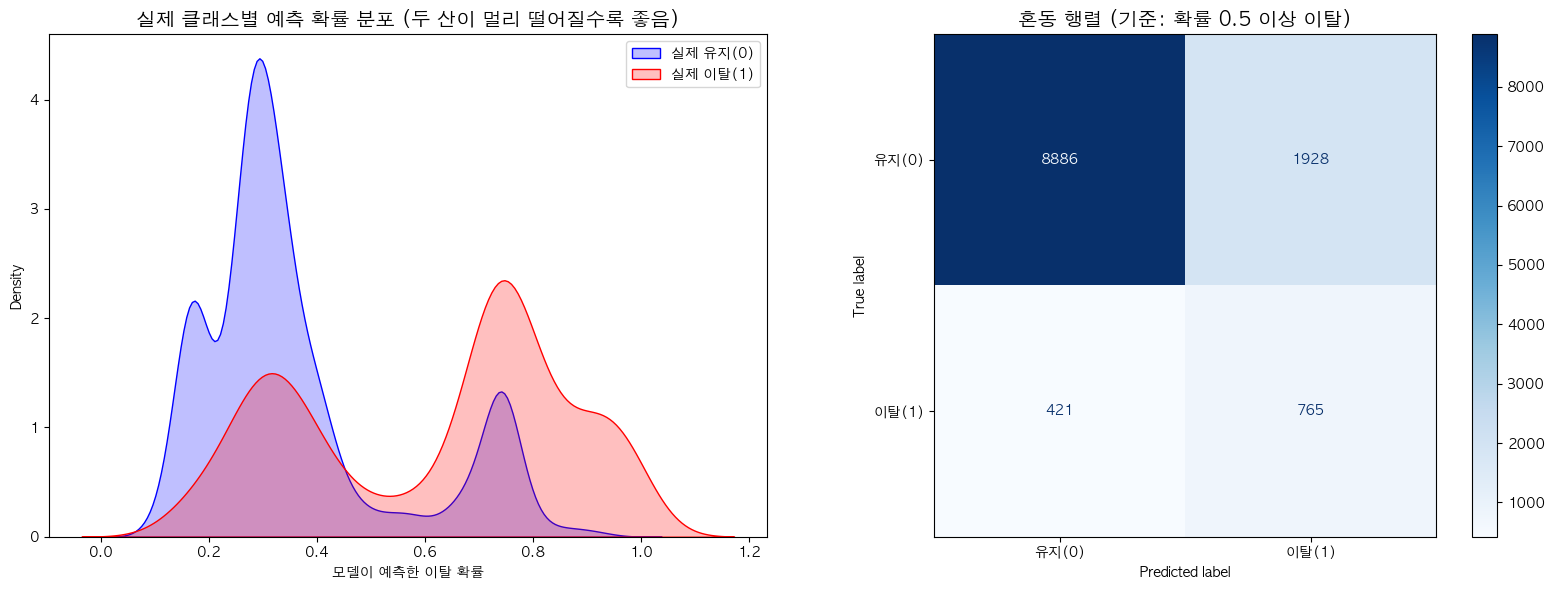

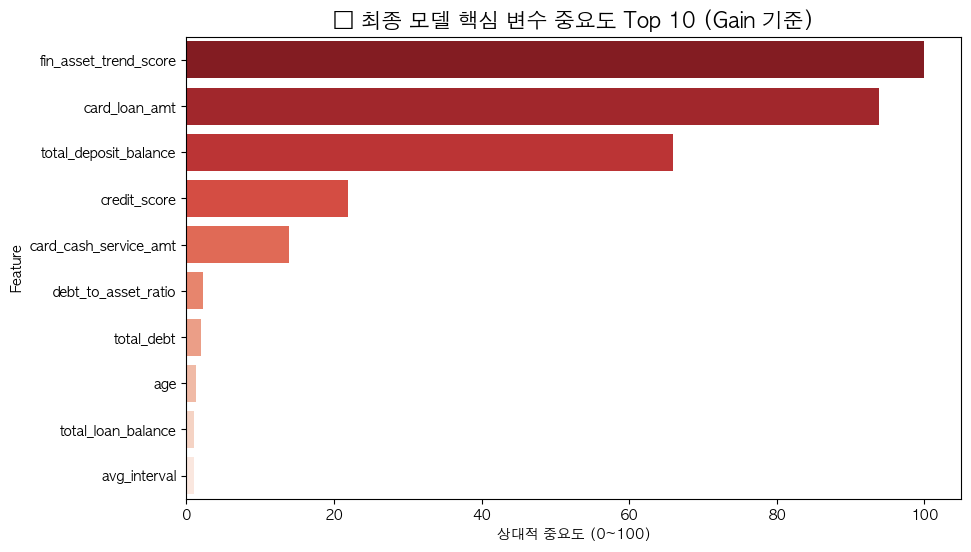

In [11]:
print("🔍 최종 모델 예측 결과 정밀 분석을 시작합니다...\n")

# 한글 폰트 깨짐 방지 (맥OS는 'AppleGothic', 윈도우는 'Malgun Gothic' 사용)
plt.rcParams['font.family'] = 'AppleGothic' # 윈도우라면 'Malgun Gothic'으로 변경!
plt.rcParams['axes.unicode_minus'] = False

# ==============================================================================
# 1. 눈으로 직접 확인하는 예측 결과 데이터프레임 만들기
# ==============================================================================
# 검증 데이터(X_valid)에 실제 정답과 예측 확률을 붙입니다.
results_df = X_valid.copy()
results_df['Actual_Churn'] = y_valid
results_df['Predicted_Prob'] = valid_preds

# 예측 오차(Error) 계산: 1에 가까울수록 모델이 완벽하게 헛짚었다는 뜻
results_df['Error_Gap'] = abs(results_df['Actual_Churn'] - results_df['Predicted_Prob'])

print("🚨 [분석 필수] 모델이 완벽하게 속아넘어간 워스트 케이스 Top 10")
print("-> 실제 이탈(1)인데 확률이 0.01이거나, 유지(0)인데 0.99로 예측한 치명적 오답들입니다.")
worst_cases = results_df.sort_values(by='Error_Gap', ascending=False).head(10)
display(worst_cases[['Actual_Churn', 'Predicted_Prob', 'Error_Gap'] + features[:5]]) # 앞부분 피처만 살짝 보기

# ==============================================================================
# 2. 오차 분석 시각화 (예측 확률 분포도)
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# [그래프 1] 클래스별 예측 확률 분포 (Density Plot)
sns.kdeplot(data=results_df[results_df['Actual_Churn']==0], x='Predicted_Prob', fill=True, color='blue', label='실제 유지(0)', ax=axes[0])
sns.kdeplot(data=results_df[results_df['Actual_Churn']==1], x='Predicted_Prob', fill=True, color='red', label='실제 이탈(1)', ax=axes[0])
axes[0].set_title('실제 클래스별 예측 확률 분포 (두 산이 멀리 떨어질수록 좋음)', fontsize=14)
axes[0].set_xlabel('모델이 예측한 이탈 확률')
axes[0].legend()

# [그래프 2] 혼동 행렬 (임계값 0.5 기준)
THRESHOLD = 0.5
predicted_class = (valid_preds >= THRESHOLD).astype(int)
cm = confusion_matrix(y_valid, predicted_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['유지(0)', '이탈(1)'])
disp.plot(cmap='Blues', ax=axes[1], values_format='d')
axes[1].set_title(f'혼동 행렬 (기준: 확률 {THRESHOLD} 이상 이탈)', fontsize=14)

plt.tight_layout()
plt.show()

# ==============================================================================
# 3. 최종 모델의 피처 중요도 (Gain 기준)
# ==============================================================================
# SMOTE와 Optuna를 거친 최종 모델은 과연 어떤 변수를 보고 판단했을까?
feature_imp = pd.DataFrame({
    'Feature': features,
    'Importance': final_model.booster_.feature_importance(importance_type='gain')
})

# 100점 만점으로 스케일링
feature_imp['Importance'] = 100 * (feature_imp['Importance'] / feature_imp['Importance'].max())
feature_imp = feature_imp.sort_values(by='Importance', ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp.head(10), palette='Reds_r')
plt.title('🔥 최종 모델 핵심 변수 중요도 Top 10 (Gain 기준)', fontsize=15)
plt.xlabel('상대적 중요도 (0~100)')
plt.show()